In [341]:
import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import emoji
import string
import re

In [321]:
df = pd.read_csv("goud_articles.csv")
df.head()

,title,url,category,content,published_time,modified_time
0,استعدادا للمونديال.. حموشي عين مسؤولين أمنيين ...,https://www.goud.ma/%d8%ad%d9%85%d9%88%d8%b4%d...,آش واقع,أنس العمري-كود///\nأشر المدير العام للأمن الوط...,2025-08-06 20:12:57+00:00,2025-08-06T21:00:07+00:00
1,قرار محكمة العدل الاوربية. وزير خارجية الصبليو...,https://www.goud.ma/%d9%82%d8%b1%d8%a7%d8%b1-%...,آش واقع,مدريد و م ع///\nأعرب وزير الشؤون الخارجية الاس...,2024-10-04 15:43:02+00:00,NaN
2,تحديد مواعيد مؤجلات الرجا وليفار وبركان وماتشا...,https://www.goud.ma/%d8%aa%d8%ad%d8%af%d9%8a%d...,كود سبور,كود سبور//\nحددت العصبة الوطنية لكرة القدم الا...,2025-01-12 21:06:45+00:00,NaN
3,الأرصاد الجوية: الصهد فهاد المناطق والغيام فال...,https://www.goud.ma/%d8%a7%d9%84%d8%a3%d8%b1%d...,آش واقع,عمر المزين – كود//\nتوقعات المديرية العامة للأ...,2025-05-06 08:48:42+00:00,NaN
4,تقرير: نتنياهو باغي يعرض خطط جديدة لضرب إيران ...,https://www.goud.ma/%d8%aa%d9%82%d8%b1%d9%8a%d...,جورنالات بلادي,وكالات//\nتستعد إسرائيل لطرح ملف حساس على طاول...,2025-12-20 22:00:55+00:00,2025-12-20T22:03:12+00:00


In [322]:
df = df.drop(["url", "published_time", "modified_time"], axis=1)

In [323]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 8241
Total Features (columns): 3


In [324]:
print(df.dtypes)

title       object
category    object
content     object
dtype: object


In [325]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])
if (duplicate_count > 0):
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate values detected in the data.")

2 Duplicate values found in the data.


In [326]:
#Check null values
missing = df.isnull().sum()
print("Missing Values : ", missing[missing > 0])

Missing Values :  content    7
dtype: int64


In [327]:
df.dropna(inplace=True)

In [328]:
df["category"].unique()

array(['آش واقع', 'كود سبور', 'جورنالات بلادي', 'ميديا وثقافة',
       'الرئيسية', 'تبركيك', 'آراء', 'كود-تيفي', 'الزين والحداكة',
       'راس السوق', 'كود'], dtype=object)

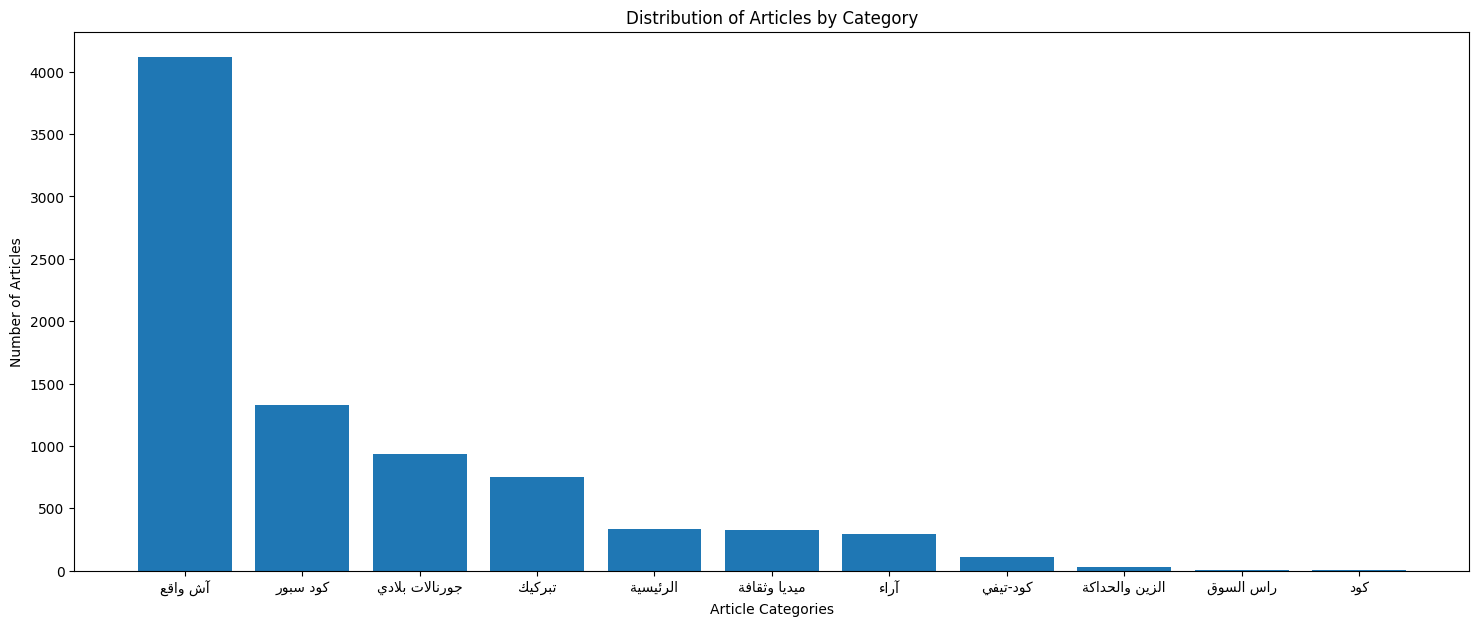

In [329]:
categories_count = df["category"].value_counts()
categories = categories_count.keys().to_list()

for i, category in enumerate(categories):
    categories[i] = get_display(arabic_reshaper.reshape(category))

plt.figure(figsize=(18, 7))
plt.bar(categories, categories_count.values)
plt.title("Distribution of Articles by Category")
plt.xlabel("Article Categories")
plt.ylabel("Number of Articles")
plt.show()

In [330]:
def clean_first_line(text):
    lines = text.split('\n')
    if '/' in lines[0]:
        return '\n'.join(lines[1:]).strip()
    return text

original = df["content"].copy()
df["content"] = df["content"].apply(clean_first_line)

counter = (df["content"] != original).sum()
print(f"Cleaned: {counter}")

Cleaned: 8205


In [331]:
print(f"Empty strings: {(df['content'] == '').sum()}")

Empty strings: 8


In [332]:
df = df[df["content"].str.strip() != ""]

In [333]:
def get_first_paragraph(text):
    match = re.search(r'[.!?؟]', text)
    if match:
        return text[:match.end()].strip()
    return text.strip()

In [334]:
df["first_paragraph"] = df["content"].apply(get_first_paragraph)

In [335]:
for i in range(5):
    print(df["first_paragraph"].iloc[i])
    print("_____________" * 10)

أشر المدير العام للأمن الوطني، عبد اللطيف حموشي، ظهر اليوم الأربعاء، على قائمة جديدة تتضمن تعيين 24 مسؤولا جديدا في مناصب المسؤولية للتدبير الإداري والعملياتي للمصالح المركزية والجهوية للأمن الوطني.
__________________________________________________________________________________________________________________________________
أعرب وزير الشؤون الخارجية الاسباني، خوسي مانويل ألباريس، اليوم الجمعة، عن احترام حكومة بلاده لقرار محكمة العدل الأوروبية المتعلق باتفاقيتي الفلاحة والصيد البحري بين الاتحاد الأوروبي والمغرب، مدافعا في نفس الوقت عن “الشراكة الاستراتيجية” مع المملكة المغربية ومؤكدا إرادة الحفاظ عليها.
__________________________________________________________________________________________________________________________________
حددت العصبة الوطنية لكرة القدم الاحترافية، مواعيد الماتشات المؤجلة عن الجولتين 17 و 18 و 19 بالنسبة للفرق اللي مشاركة فالمسابقات الافريقية.
___________________________________________________________________________________________________________________

In [336]:
df["first_paragraph_length"] = df["first_paragraph"].apply(len)
df["first_paragraph_length"].describe()

count    8223.000000
mean      194.087559
std        95.189192
min         2.000000
25%       140.000000
50%       182.000000
75%       231.000000
max      1820.000000
Name: first_paragraph_length, dtype: float64

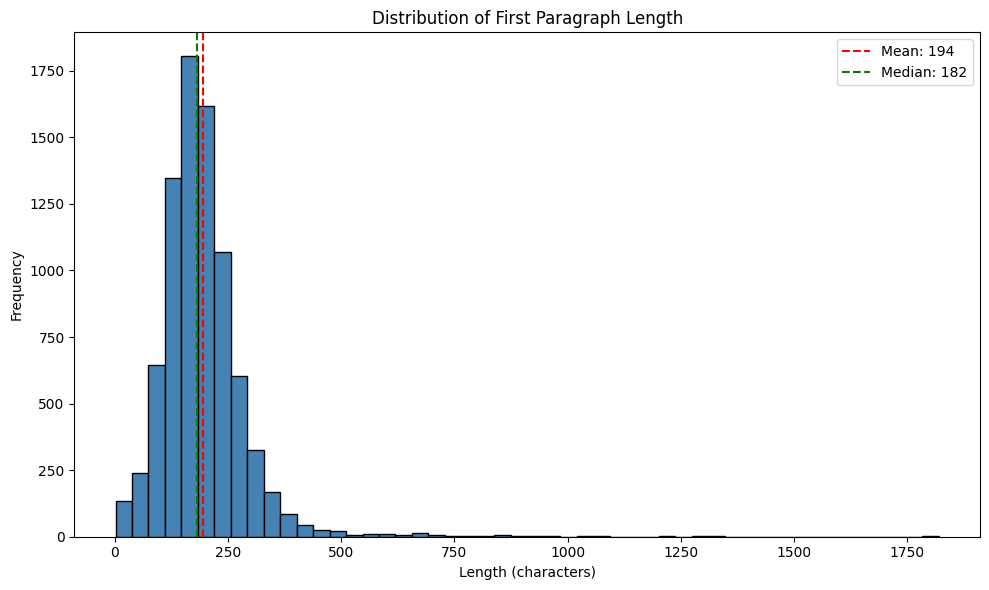

In [337]:
plt.figure(figsize=(10, 6))
plt.hist(df["first_paragraph_length"], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution of First Paragraph Length")
plt.xlabel("Length (characters)")
plt.ylabel("Frequency")
plt.axvline(df["first_paragraph_length"].mean(), color='red', linestyle='--', label=f'Mean: {df["first_paragraph_length"].mean():.0f}')
plt.axvline(df["first_paragraph_length"].median(), color='green', linestyle='--', label=f'Median: {df["first_paragraph_length"].median():.0f}')
plt.legend()
plt.tight_layout()
#plt.show()

In [338]:
# The data is right-skewed (many short texts, few very long ones)

min_length = 50
max_length = 500

before = len(df)
df = df[df["first_paragraph_length"].between(min_length, max_length)]
after = len(df)

print(f"Before: {before}")
print(f"After:  {after}")
print(f"Removed: {before - after}")

Before: 8223
After:  7939
Removed: 284


In [342]:
df["first_paragraph_length"].describe()

count    7939.000000
mean      191.726414
std        70.150806
min        50.000000
25%       143.000000
50%       183.000000
75%       230.000000
max       494.000000
Name: first_paragraph_length, dtype: float64